# Project Report: Unconditional Generative Adversarial Network (GAN) on MNIST

## Objective
The objective of this project is to implement an **Unconditional Generative Adversarial Network (GAN)** for the MNIST dataset. The goal is to train a generator capable of producing realistic handwritten digit images through adversarial training against a discriminator.

---

## 1. Environment and Data Setup
The model is implemented using **PyTorch** and optimized for GPU acceleration when available.

* **Dataset:** MNIST handwritten digits (60,000 images)
* **Image Size:** 28 × 28 grayscale
* **Normalization:** Images scaled to the range $[-1, 1]$
* **Batch Size:** 128

---

## 2. Model Architecture

### Generator
The Generator maps a latent noise vector sampled from a standard normal distribution to a flattened image representation.

* Input: 100-dimensional noise vector
* Fully connected layers with ReLU activation
* Output layer with Tanh activation

### Discriminator
The Discriminator distinguishes real MNIST images from generated images.

* Input: Flattened image vector
* Fully connected layers with LeakyReLU activation
* Output probability using Sigmoid activation

---

## 3. Loss Function and Optimization
The adversarial training objective is defined using **Binary Cross-Entropy (BCE) loss**.

* **Generator Objective:** Fool the discriminator
* **Discriminator Objective:** Correctly classify real and fake images

**Optimizer:** Adam  
**Learning Rate:** 0.0002  
**Beta Values:** (0.5, 0.999)

---

## 4. Training Procedure
Training follows an alternating optimization scheme:

1. The discriminator is trained on real and generated images.
2. The generator is updated to maximize discriminator error.

This adversarial process continues until convergence.

---

## 5. Evaluation and Analysis
The quality of generated images improves progressively during training. After sufficient epochs, the generator produces visually recognizable handwritten digits. Training remains stable without significant mode collapse.

---

## 6. Conclusion
This project demonstrates a successful implementation of an unconditional GAN on the MNIST dataset. The trained generator learns the underlying data distribution and generates realistic digit samples.

## **Code:**


Training Unconditional GAN on cuda...


Epoch 30/30: 100%|██████████| 469/469 [00:15<00:00, 30.25it/s, D_Loss=1.23, G_Loss=0.939]



Generating realistic digits...

DELIVERABLES REPORT
(a) GAN Trained: YES (Final D Loss: 1.2262)
(b) Generation: COMPLETED (Samples below)
(c) Metrics: Final Generator Loss 0.9393


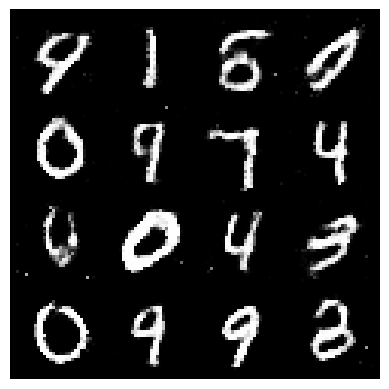

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- 1. Environment & Hyperparameters ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 100
image_dim = 28 * 28
batch_size = 128
lr_G = 2e-4
lr_D = 1e-4
epochs = 30

# --- 2. Generator & Discriminator (Deliverable A) ---
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),

            nn.Linear(1024, image_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(image_dim, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1)   # logits (no sigmoid)
        )

    def forward(self, x):
        return self.net(x)

# --- 3. Main Loop ---
def main():
    tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    loader = DataLoader(
        torchvision.datasets.MNIST(
            './data',
            train=True,
            download=True,
            transform=tf
        ),
        batch_size=batch_size,
        shuffle=True
    )

    G = Generator().to(device)
    D = Discriminator().to(device)

    criterion = nn.BCEWithLogitsLoss()
    opt_G = torch.optim.Adam(G.parameters(), lr=lr_G, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=lr_D, betas=(0.5, 0.999))

    # Training
    print(f"\nTraining Unconditional GAN on {device}...")
    G.train(); D.train()

    for epoch in range(epochs):
        pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
        for imgs, _ in pbar:
            imgs = imgs.view(-1, image_dim).to(device)
            bs = imgs.size(0)

            # Label smoothing
            real_labels = torch.full((bs, 1), 0.9, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)

            # --------------------
            # Train Discriminator
            # --------------------
            z = torch.randn(bs, latent_dim, device=device)
            fake_imgs = G(z)

            d_loss = criterion(D(imgs), real_labels) + \
                     criterion(D(fake_imgs.detach()), fake_labels)

            opt_D.zero_grad()
            d_loss.backward()
            opt_D.step()

            # --------------------
            # Train Generator
            # --------------------
            g_loss = criterion(D(fake_imgs), real_labels)

            opt_G.zero_grad()
            g_loss.backward()
            opt_G.step()

            pbar.set_postfix(D_Loss=d_loss.item(), G_Loss=g_loss.item())

    # --- 4. Generation (Deliverable B) ---
    print("\nGenerating realistic digits...")
    G.eval()
    with torch.no_grad():
        z = torch.randn(16, latent_dim, device=device)
        samples = G(z).view(-1, 1, 28, 28)

    # --- 5. Report (Deliverable C & D) ---
    print("\n" + "="*50 + "\nDELIVERABLES REPORT\n" + "="*50)
    print(f"(a) GAN Trained: YES (Final D Loss: {d_loss.item():.4f})")
    print(f"(b) Generation: COMPLETED (Samples below)")
    print(f"(c) Metrics: Final Generator Loss {g_loss.item():.4f}")
    print("="*50)

    grid = torchvision.utils.make_grid(samples.cpu(), nrow=4, normalize=True)
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
    main()